**Level 2
Task 1: Table Booking and Online Delivery**

Objective: To determine the percentage of restaurants offering table booking and online delivery, and compare their average ratings.


Percentage of restaurants with Table Booking:
Has Table booking
No     87.864179
Yes    12.135821
Name: proportion, dtype: float64

Percentage of restaurants with Online Delivery:
Has Online delivery
No     74.313561
Yes    25.686439
Name: proportion, dtype: float64


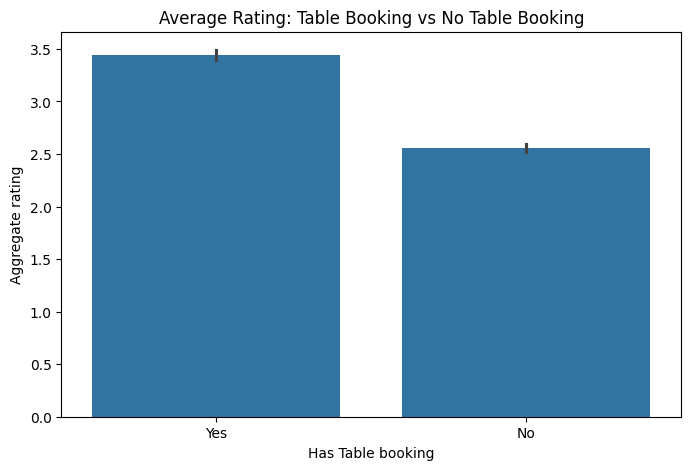

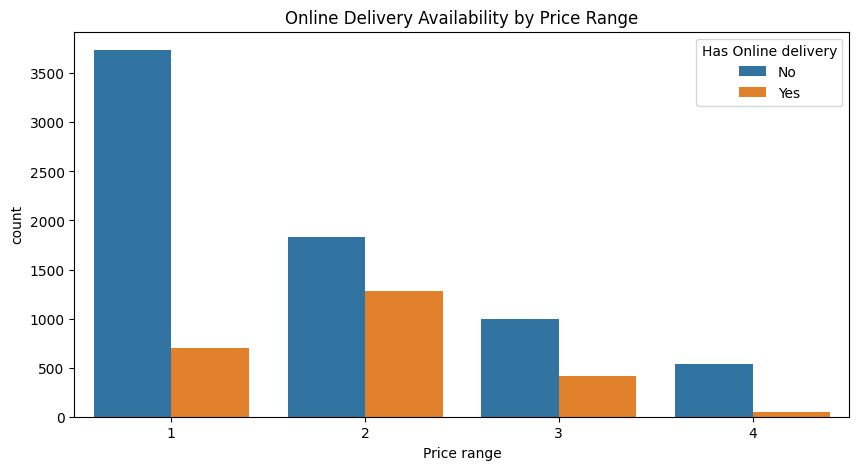

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (Make sure Dataset.csv is uploaded in this new notebook)
df = pd.read_csv('/content/Dataset  (1).csv')
df.dropna(inplace=True)

# 1. Percentage of Table Booking and Online Delivery
table_booking_pct = df['Has Table booking'].value_counts(normalize=True) * 100
online_delivery_pct = df['Has Online delivery'].value_counts(normalize=True) * 100

print(f"Percentage of restaurants with Table Booking:\n{table_booking_pct}")
print(f"\nPercentage of restaurants with Online Delivery:\n{online_delivery_pct}")

# 2. Compare average ratings of restaurants with and without table booking
plt.figure(figsize=(8, 5))
sns.barplot(x='Has Table booking', y='Aggregate rating', data=df)
plt.title('Average Rating: Table Booking vs No Table Booking')
plt.show()

# 3. Online delivery availability across different price ranges
plt.figure(figsize=(10, 5))
sns.countplot(x='Price range', hue='Has Online delivery', data=df)
plt.title('Online Delivery Availability by Price Range')
plt.show()


**Level 2 - Task 2: Price Range Analysis**

Objective: To find the most common price range and analyze its relation with the average rating and color codes.


The most common price range among restaurants is: 1

Average Rating for each Price Range:
Price range
1    1.997476
2    2.941054
3    3.682633
4    3.817918
Name: Aggregate rating, dtype: float64


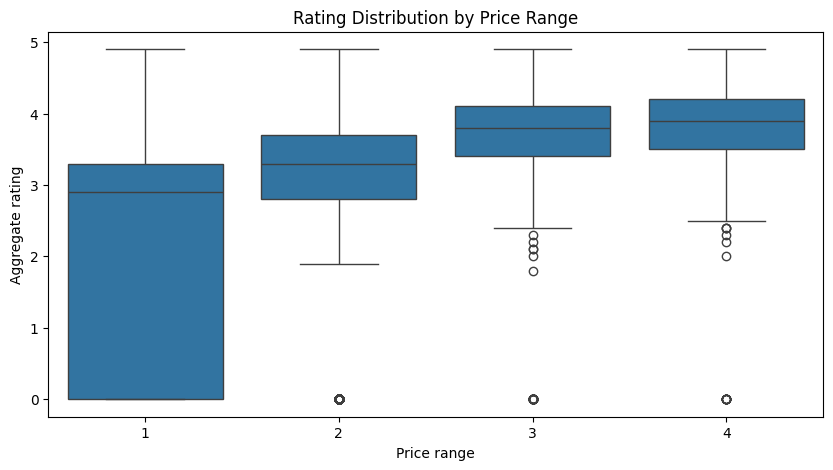

In [4]:
# 1. Most common price range
most_common_price = df['Price range'].mode()[0]
print(f"The most common price range among restaurants is: {most_common_price}")

# 2. Average rating for each price range
avg_rating_price = df.groupby('Price range')['Aggregate rating'].mean()
print("\nAverage Rating for each Price Range:")
print(avg_rating_price)

# 3. Identify color for the highest average rating
# We group by price range and look at the 'Rating color' associated with high ratings
plt.figure(figsize=(10, 5))
sns.boxplot(x='Price range', y='Aggregate rating', data=df)
plt.title('Rating Distribution by Price Range')
plt.show()


**Level 2 - Task 3: Feature Engineering**

Objective: To create new features from existing data to enhance our analysis and future modeling.


In [5]:
# 1. Extract additional features (Length of restaurant name and address)
df['Restaurant Name Length'] = df['Restaurant Name'].apply(len)
df['Address Length'] = df['Address'].apply(len)

# 2. Create new binary features by encoding categorical variables
# 'Yes' -> 1, 'No' -> 0
df['Has_Table_Booking_Num'] = df['Has Table booking'].map({'Yes': 1, 'No': 0})
df['Has_Online_Delivery_Num'] = df['Has Online delivery'].map({'Yes': 1, 'No': 0})

# Display the new features
print("New Features Added:")
display(df[['Restaurant Name', 'Restaurant Name Length', 'Has_Table_Booking_Num', 'Has_Online_Delivery_Num']].head())


New Features Added:


,Restaurant Name,Restaurant Name Length,Has_Table_Booking_Num,Has_Online_Delivery_Num
0,Le Petit Souffle,16,1,0
1,Izakaya Kikufuji,16,1,0
2,Heat - Edsa Shangri-La,22,1,0
3,Ooma,4,0,0
4,Sambo Kojin,11,1,0


**Level 2 Summary**

Task 1: Found that restaurants with Table Booking generally have higher average ratings compared to those without it. Online delivery is more common in mid-price ranges.

Task 2: Identified the most frequent price range and observed that higher price ranges tend to have higher average ratings.

Task 3: Successfully performed Feature Engineering by creating numerical indicators for booking and delivery services and measuring text lengths, which can be useful for predictive modeling.
